# 04_clustering.ipynb - Clustering Multi-Modelo para Índice de Resiliencia Territorial

Este notebook implementa **clustering independiente por escenario** sobre el espacio latente de **3 modelos de autoencoder** para construir y comparar **índices de resiliencia territorial** en el Valle de Aconcagua.

## 🎯 Hipótesis de Trabajo:

**Clusterizando el espacio latente del autoencoder podemos identificar perfiles climático-energéticos territoriales, y derivar un índice de resiliencia INDEPENDIENTE para cada escenario SSP que mida la capacidad de cada zona para sostener producción H2V bajo diferentes condiciones climáticas futuras.**

## 🆕 NOVEDAD: Comparación Multi-Modelo

Este notebook procesa **3 modelos de autoencoder** entrenados en 04a_latent_visualization:
- **Model_A** (7D latente - baseline)
- **Model_B** (12D latente - intermedio)
- **Model_C** (15D latente - complejo)

Para cada modelo:
1. Clustering independiente por escenario SSP
2. Cálculo de índice de resiliencia territorial
3. Validación y comparación

**Objetivo**: Determinar si la elección del modelo afecta las conclusiones de resiliencia.

## ⚠️ ENFOQUE CORRECTO:

### 1. **Clustering Independiente por Escenario**
- Entrenar **3 modelos K-means separados** (SSP245, SSP370, SSP585) **para cada modelo de autoencoder**
- Total: 9 modelos K-means (3 escenarios × 3 modelos de autoencoder)
- Cada escenario descubre sus propios perfiles territoriales
- Los cluster IDs NO son comparables directamente entre escenarios

### 2. **Índice de Resiliencia POR ESCENARIO (NO entre escenarios)**

**CRÍTICO**: Calculamos **9 índices en total** (3 modelos × 3 escenarios):
- Para cada modelo: `resilience_ssp245`, `resilience_ssp370`, `resilience_ssp585`
- Comparación inter-modelo: ¿Model_A vs Model_B vs Model_C predicen resiliencias similares?
- Comparación inter-escenario: ¿Cómo cambia la resiliencia con mayor forzamiento?

#### Componentes del Índice (por escenario y modelo):

**A. Cohesión del Cluster (0-1)**
```
cohesion = 1 - (distancia_al_centroide / max_distancia_cluster)
```
Píxeles típicos de su cluster son más estables.

**B. Condiciones Favorables para H2V (0-1)**
```
favorabilidad = score(rsds_alta, pr_estable, cdd_baja, temp_moderada)
```
Condiciones propicias para producción H2V.

**C. Estabilidad del Cluster (0-1)**
```
estabilidad = 1 - (std_intra_cluster / std_global)
```
Clusters homogéneos = más predecibles.

**D. Exposición a Extremos (0-1)**
```
exposicion_inv = 1 - percentil_global(CDD + temp_extrema)
```
Baja exposición a extremos climáticos.

**E. Índice Compuesto**
```
resilience_ssp{X} = 0.25*cohesion + 0.40*favorabilidad + 0.20*estabilidad + 0.15*exposicion_inv
```

### 3. **Validación del Índice (por modelo)**
- Coherencia espacial (autocorrelación Moran's I) por escenario
- Correlación con variables físicas (rsds, pr, CDD, Tmax) por escenario
- Comparación entre escenarios (Δresilience)
- Robustez al número de clusters (k=3,4,5)
- **NUEVO**: Comparación inter-modelo (correlación entre índices)

---

## 📊 Objetivos Específicos:

1. ✅ Cargar embeddings de los 3 modelos (del 04a)
2. ✅ Clustering independiente por escenario y modelo (9 modelos K-means)
3. ✅ Calcular índices de resiliencia (9 índices)
4. ✅ Comparar índices entre modelos (consistencia)
5. ✅ Validar con métricas espaciales y físicas
6. ✅ Generar reportes comparativos multi-modelo
7. ✅ Exportar resultados para notebook 05_resilience.ipynb

---

**Nota Crítica**: NO calcular resiliencia como "cambio entre escenarios". Cada escenario tiene su propia resiliencia territorial, calculada independientemente para cada modelo.

In [65]:
# === Configuración y Rutas ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.manifold import TSNE
from scipy.spatial.distance import euclidean, cdist
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Rutas principales
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
RESULTS_DIR = BASE_DIR / 'data' / 'autoencoder_results'
PLOTS_DIR = BASE_DIR / 'plots' / 'resilience_analysis'
REPORTS_DIR = BASE_DIR / 'reports'

# Crear directorios
PLOTS_DIR.mkdir(exist_ok=True, parents=True)
REPORTS_DIR.mkdir(exist_ok=True, parents=True)

# Configuración de clustering
MODE = 'test'  # 'test' o 'full'
K_VALUES = [3, 4, 5]  # Probar múltiples k para validación de robustez
K_OPTIMAL = 4  # Elegir después de exploración (empezar con 4)

# NUEVO: Cargar información de modelos entrenados desde análisis 04a
results_file = RESULTS_DIR / f'multi_model_comparison_{MODE}.json'

if results_file.exists():
    with open(results_file, 'r') as f:
        multi_model_results = json.load(f)
    
    # Filtrar solo modelos completados
    MODELS = [m for m in multi_model_results.keys() if multi_model_results[m]['status'] == 'completed']
    
    print(f"\n✅ Modelos cargados desde 04a_latent_visualization:")
    for model in MODELS:
        info = multi_model_results[model]
        print(f"   {model}: {info['latent_dim']}D, MSE={info['test_mse']:.6f}")
else:
    # Fallback a configuración manual
    MODELS = ['Model_A', 'Model_B', 'Model_C']
    print(f"\n⚠️  No se encontró archivo de resultados multi-modelo.")
    print(f"   Usando configuración manual: {MODELS}")

# Cargar recomendación (si existe) para destacar modelo preferido
recommendation_file = RESULTS_DIR / f'latent_space_recommendation_{MODE}.json'
RECOMMENDED_MODEL = None

if recommendation_file.exists():
    with open(recommendation_file, 'r') as f:
        recommendation = json.load(f)
    RECOMMENDED_MODEL = recommendation['recommended_model']
    print(f"\n⭐ Modelo recomendado: {RECOMMENDED_MODEL} (composite_score={recommendation['composite_score']:.4f})")

# Pesos para índice de resiliencia (ajustables)
WEIGHTS = {
    'cohesion': 0.25,          # Cohesión al centroide del cluster
    'favorabilidad': 0.40,     # Condiciones favorables para H2V
    'estabilidad_cluster': 0.20,  # Estabilidad interna del cluster
    'exposicion_inv': 0.15     # Inverso de exposición a extremos
}

print("=" * 80)
print("🔍 CLUSTERING MULTI-MODELO PARA ÍNDICE DE RESILIENCIA TERRITORIAL")
print("=" * 80)
print(f"\n📁 Directorios:")
print(f"   Resultados: {RESULTS_DIR}")
print(f"   Plots: {PLOTS_DIR}")
print(f"   Reportes: {REPORTS_DIR}")
print(f"\n⚙️ Configuración:")
print(f"   Modelos a procesar: {MODELS}")
print(f"   Modo: {MODE}")
print(f"   K values a probar: {K_VALUES}")
print(f"   K óptimo inicial: {K_OPTIMAL}")
print(f"\n🎯 Pesos del índice (POR ESCENARIO):")
for component, weight in WEIGHTS.items():
    print(f"   {component}: {weight}")
print(f"\n⚠️  IMPORTANTE: Se calcularán 9 índices (3 modelos × 3 escenarios)")
print("=" * 80)


✅ Modelos cargados desde 04a_latent_visualization:
   Model_A: 7D, MSE=0.027640
   Model_B: 12D, MSE=0.021742
   Model_C: 15D, MSE=0.020685

⭐ Modelo recomendado: Model_C (composite_score=1.0000)
🔍 CLUSTERING MULTI-MODELO PARA ÍNDICE DE RESILIENCIA TERRITORIAL

📁 Directorios:
   Resultados: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_results
   Plots: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_analysis
   Reportes: /home/aninotna/magister/tesis/justh2_pipeline/reports

⚙️ Configuración:
   Modelos a procesar: ['Model_A', 'Model_B', 'Model_C']
   Modo: test
   K values a probar: [3, 4, 5]
   K óptimo inicial: 4

🎯 Pesos del índice (POR ESCENARIO):
   cohesion: 0.25
   favorabilidad: 0.4
   estabilidad_cluster: 0.2
   exposicion_inv: 0.15

⚠️  IMPORTANTE: Se calcularán 9 índices (3 modelos × 3 escenarios)


## 📥 1. Cargar Datos del Autoencoder (Todos los Modelos)

Cargar embeddings (espacio latente), datos originales, y metadatos espaciales para **los 3 modelos entrenados**.

**CRÍTICO**: NO cargar modelos K-means pre-entrenados. Entrenaremos nuevos modelos independientes por escenario y por modelo de autoencoder.

In [66]:
# Cargar embeddings de TODOS los modelos
print(f"\n{'='*80}")
print(f"📂 CARGANDO EMBEDDINGS DE {len(MODELS)} MODELOS")
print(f"{'='*80}")

models_data = {}

for model_name in MODELS:
    print(f"\n🔄 Procesando {model_name}...")
    
    embedding_file = RESULTS_DIR / f'{model_name}_embeddings_{MODE}.pkl'
    
    if not embedding_file.exists():
        print(f"   ⚠️  No encontrado: {embedding_file.name}")
        continue
    
    print(f"   ✅ Cargando: {embedding_file.name}")
    
    with open(embedding_file, 'rb') as f:
        embedding_data = pickle.load(f)
    
    # Extraer embeddings
    embeddings_train = embedding_data['train']
    embeddings_val = embedding_data['val']
    embeddings_test = embedding_data['test']
    
    scenario_labels_train = embedding_data['scenario_labels_train']
    scenario_labels_val = embedding_data['scenario_labels_val']
    scenario_labels_test = embedding_data['scenario_labels_test']
    
    # Combinar todos los splits
    embeddings_all = np.concatenate([embeddings_train, embeddings_val, embeddings_test], axis=0)
    scenario_labels_all = np.concatenate([scenario_labels_train, scenario_labels_val, scenario_labels_test], axis=0)
    
    # Convertir labels a string (si son integers)
    if scenario_labels_all.dtype != 'object':
        scenario_map = {0: 'ssp245', 1: 'ssp370', 2: 'ssp585'}
        scenario_labels_str = np.array([scenario_map[int(x)] for x in scenario_labels_all])
    else:
        scenario_labels_str = scenario_labels_all
    
    # Separar por escenario
    embeddings_ssp245 = embeddings_all[scenario_labels_str == 'ssp245']
    embeddings_ssp370 = embeddings_all[scenario_labels_str == 'ssp370']
    embeddings_ssp585 = embeddings_all[scenario_labels_str == 'ssp585']
    
    # Guardar en diccionario
    models_data[model_name] = {
        'embeddings_all': embeddings_all,
        'scenario_labels_all': scenario_labels_str,
        'embeddings_ssp245': embeddings_ssp245,
        'embeddings_ssp370': embeddings_ssp370,
        'embeddings_ssp585': embeddings_ssp585,
        'latent_dim': embedding_data['latent_dim'],
        'feature_names': embedding_data.get('feature_names', [f'var_{i}' for i in range(293)]),
        'spatial_info': embedding_data.get('spatial_info', None),
        'mask': embedding_data.get('mask', None),
        'grid_shape': embedding_data.get('grid_shape', None),
        'extent': embedding_data.get('extent', None),
    }
    
    print(f"   ✅ {model_name} cargado:")
    print(f"      Latent dim: {embedding_data['latent_dim']}")
    print(f"      SSP245: {embeddings_ssp245.shape}")
    print(f"      SSP370: {embeddings_ssp370.shape}")
    print(f"      SSP585: {embeddings_ssp585.shape}")

print(f"\n{'='*80}")
print(f"✅ CARGA COMPLETADA: {len(models_data)} modelos")
print(f"{'='*80}")

# Verificar información espacial (debe ser la misma para todos)
print(f"\n📍 Verificando información espacial...")

first_model = list(models_data.keys())[0]
spatial_ref = models_data[first_model]

# Extraer información espacial (priorizar spatial_info si existe)
if spatial_ref['spatial_info'] is not None:
    spatial_info = spatial_ref['spatial_info']
    mask = spatial_info.get('mask', spatial_ref['mask'])
    grid_shape = spatial_info.get('grid_shape', spatial_ref['grid_shape'])
    lat_coords = spatial_info.get('lat_coords', spatial_info.get('lat'))
    lon_coords = spatial_info.get('lon_coords', spatial_info.get('lon'))
    extent = spatial_info.get('extent', spatial_ref['extent'])
else:
    mask = spatial_ref['mask']
    grid_shape = spatial_ref['grid_shape']
    # Cargar desde metadata separada si es necesario
    tensors_dir = BASE_DIR / 'data' / 'autoencoder_tensors'
    metadata_file = tensors_dir / f'metadata_{MODE}.pkl'
    
    if metadata_file.exists():
        with open(metadata_file, 'rb') as f:
            metadata = pickle.load(f)
        lat_coords = metadata['spatial_info'].get('lat')
        lon_coords = metadata['spatial_info'].get('lon')
        extent = metadata.get('extent')
    else:
        lat_coords = None
        lon_coords = None
        extent = None

if mask is not None:
    print(f"   ✅ Grid espacial: {grid_shape}")
    print(f"   ✅ Píxeles válidos: {mask.sum()}")
    if extent is not None:
        print(f"   ✅ Extent: {extent}")
else:
    print(f"   ⚠️  Información espacial no disponible en embeddings")
    print(f"   ℹ️  Se cargará desde metadata separada más adelante")

# Guardar referencias globales para uso posterior
MASK = mask
GRID_SHAPE = grid_shape
LAT_COORDS = lat_coords
LON_COORDS = lon_coords
EXTENT = extent

print(f"\n{'='*80}")


📂 CARGANDO EMBEDDINGS DE 3 MODELOS

🔄 Procesando Model_A...
   ✅ Cargando: Model_A_embeddings_test.pkl
   ✅ Model_A cargado:
      Latent dim: 7
      SSP245: (661, 7)
      SSP370: (661, 7)
      SSP585: (661, 7)

🔄 Procesando Model_B...
   ✅ Cargando: Model_B_embeddings_test.pkl
   ✅ Model_B cargado:
      Latent dim: 12
      SSP245: (661, 12)
      SSP370: (661, 12)
      SSP585: (661, 12)

🔄 Procesando Model_C...
   ✅ Cargando: Model_C_embeddings_test.pkl
   ✅ Model_C cargado:
      Latent dim: 15
      SSP245: (661, 15)
      SSP370: (661, 15)
      SSP585: (661, 15)

✅ CARGA COMPLETADA: 3 modelos

📍 Verificando información espacial...
   ⚠️  Información espacial no disponible en embeddings
   ℹ️  Se cargará desde metadata separada más adelante



## 🔬 2. Clustering Multi-Modelo Independiente por Escenario

Entrenar **9 modelos K-means** (3 modelos de autoencoder × 3 escenarios SSP) para identificar perfiles climático-energéticos territoriales.

In [67]:
# Clustering multi-modelo por escenario
print(f"\n{'='*80}")
print(f"🔬 CLUSTERING INDEPENDIENTE POR ESCENARIO Y MODELO")
print(f"{'='*80}")

clustering_results = {}

for model_name in models_data.keys():
    print(f"\n🔄 Procesando {model_name}...")
    
    model_data = models_data[model_name]
    clustering_results[model_name] = {}
    
    # Entrenar K-means para cada escenario
    for scenario in ['ssp245', 'ssp370', 'ssp585']:
        embeddings_scenario = model_data[f'embeddings_{scenario}']
        
        print(f"\n   Escenario {scenario.upper()}:")
        print(f"      Samples: {embeddings_scenario.shape[0]}")
        
        # Probar múltiples k
        scenario_results = []
        
        for k in K_VALUES:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
            labels = kmeans.fit_predict(embeddings_scenario)
            
            # Métricas de calidad
            sil_score = silhouette_score(embeddings_scenario, labels)
            db_score = davies_bouldin_score(embeddings_scenario, labels)
            inertia = kmeans.inertia_
            
            scenario_results.append({
                'k': k,
                'silhouette': sil_score,
                'davies_bouldin': db_score,
                'inertia': inertia,
                'model': kmeans,
                'labels': labels
            })
            
            print(f"      k={k}: Silhouette={sil_score:.4f}, Davies-Bouldin={db_score:.4f}")
        
        # Seleccionar mejor k (mayor silhouette)
        best_result = max(scenario_results, key=lambda x: x['silhouette'])
        best_k = best_result['k']
        
        print(f"   ✅ Mejor k={best_k} para {scenario.upper()}")
        
        # Guardar resultados del mejor modelo
        clustering_results[model_name][scenario] = {
            'k_optimal': best_k,
            'all_k_results': scenario_results,
            'best_model': best_result['model'],
            'best_labels': best_result['labels'],
            'best_silhouette': best_result['silhouette'],
            'best_db': best_result['davies_bouldin'],
            'centroids': best_result['model'].cluster_centers_
        }

print(f"\n{'='*80}")
print(f"✅ CLUSTERING COMPLETADO PARA {len(clustering_results)} MODELOS")
print(f"{'='*80}")

# Resumen de k óptimos por modelo y escenario
print(f"\n📊 Resumen de k óptimos:")
print(f"{'Model':<12} {'SSP245':<8} {'SSP370':<8} {'SSP585':<8}")
print(f"{'-'*40}")
for model_name in clustering_results.keys():
    k_245 = clustering_results[model_name]['ssp245']['k_optimal']
    k_370 = clustering_results[model_name]['ssp370']['k_optimal']
    k_585 = clustering_results[model_name]['ssp585']['k_optimal']
    print(f"{model_name:<12} {k_245:<8} {k_370:<8} {k_585:<8}")


🔬 CLUSTERING INDEPENDIENTE POR ESCENARIO Y MODELO

🔄 Procesando Model_A...

   Escenario SSP245:
      Samples: 661
      k=3: Silhouette=0.3624, Davies-Bouldin=1.0458
      k=4: Silhouette=0.3557, Davies-Bouldin=1.0368
      k=5: Silhouette=0.3652, Davies-Bouldin=0.9229
   ✅ Mejor k=5 para SSP245

   Escenario SSP370:
      Samples: 661
      k=3: Silhouette=0.3034, Davies-Bouldin=1.1604
      k=4: Silhouette=0.3213, Davies-Bouldin=1.1357
      k=5: Silhouette=0.3280, Davies-Bouldin=1.0707
   ✅ Mejor k=5 para SSP370

   Escenario SSP585:
      Samples: 661
      k=3: Silhouette=0.3943, Davies-Bouldin=0.9989
      k=4: Silhouette=0.3383, Davies-Bouldin=1.0510
      k=5: Silhouette=0.3619, Davies-Bouldin=0.9933
   ✅ Mejor k=3 para SSP585

🔄 Procesando Model_B...

   Escenario SSP245:
      Samples: 661
      k=3: Silhouette=0.3255, Davies-Bouldin=1.1515
      k=5: Silhouette=0.3280, Davies-Bouldin=1.0707
   ✅ Mejor k=5 para SSP370

   Escenario SSP585:
      Samples: 661
      k=3: Sil

## 📊 3. Cargar Datos Originales para Cálculo de Resiliencia

Cargar variables climático-energéticas originales (rsds, pr, CDD, tasmax) necesarias para calcular componentes del índice de resiliencia.

In [68]:
# Cargar datos originales normalizados (X) para calcular índice de resiliencia
print(f"\n{'='*80}")
print(f"📂 CARGANDO DATOS ORIGINALES (VARIABLES CLIMÁTICO-ENERGÉTICAS)")
print(f"{'='*80}")

tensors_dir = BASE_DIR / 'data' / 'autoencoder_tensors'

# Los archivos están en formato .npz (tensors_ssp{scenario}_splits_test.npz)
tensor_files = {
    'ssp245': tensors_dir / f'tensors_ssp245_splits_{MODE}.npz',
    'ssp370': tensors_dir / f'tensors_ssp370_splits_{MODE}.npz',
    'ssp585': tensors_dir / f'tensors_ssp585_splits_{MODE}.npz'
}

# Verificar archivos
all_files_exist = all(f.exists() for f in tensor_files.values())

if all_files_exist:
    print(f"\n✅ Archivos encontrados:")
    for scenario, file_path in tensor_files.items():
        print(f"   {scenario.upper()}: {file_path.name}")
    
    # Cargar datos desde archivos .npz
    X_data = {}
    
    for scenario, file_path in tensor_files.items():
        # Cargar archivo npz
        npz_data = np.load(file_path)
        
        # Los archivos .npz contienen arrays: X_train, X_val, X_test
        # Concatenar todos los splits
        X_train = npz_data['X_train']
        X_val = npz_data['X_val']
        X_test = npz_data['X_test']
        
        X_combined = np.concatenate([X_train, X_val, X_test], axis=0)
        X_data[scenario] = X_combined
        
        print(f"\n   {scenario.upper()}:")
        print(f"      Train: {X_train.shape}")
        print(f"      Val: {X_val.shape}")
        print(f"      Test: {X_test.shape}")
        print(f"      Combined: {X_combined.shape}")
    
    # Total de variables
    n_features = X_data['ssp245'].shape[1]
    print(f"\n   Total features: {n_features}")
    
else:
    print(f"\n⚠️  Archivos .npz no encontrados.")
    print(f"   Esperado: {[f.name for f in tensor_files.values()]}")
    
    # Fallback: intentar cargar desde archivos .npy individuales
    print(f"\n   Intentando archivos .npy individuales...")
    
    tensor_files_npy = {
        'ssp245': tensors_dir / f'X_{MODE}_ssp245.npy',
        'ssp370': tensors_dir / f'X_{MODE}_ssp370.npy',
        'ssp585': tensors_dir / f'X_{MODE}_ssp585.npy'
    }
    
    all_npy_exist = all(f.exists() for f in tensor_files_npy.values())
    
    if all_npy_exist:
        X_data = {}
        for scenario, file_path in tensor_files_npy.items():
            X_data[scenario] = np.load(file_path)
            print(f"      {scenario.upper()}: {X_data[scenario].shape}")
        
        n_features = X_data['ssp245'].shape[1]
        print(f"\n   ✅ Cargado desde .npy - Total features: {n_features}")
    else:
        raise FileNotFoundError(
            f"❌ No se encontraron archivos de datos originales.\n"
            f"   Esperado (npz): {[f.name for f in tensor_files.values()]}\n"
            f"   O (npy): {[f.name for f in tensor_files_npy.values()]}\n"
            f"   Archivos disponibles: {list(tensors_dir.glob('*'))}"
        )

# Cargar nombres de features desde CSV (no están en los embeddings)
feature_names_file = tensors_dir / f'feature_names_{MODE}.csv'

if feature_names_file.exists():
    print(f"\n📋 Cargando nombres de features desde: {feature_names_file.name}")
    df_features = pd.read_csv(feature_names_file)
    feature_names = df_features['feature_name'].tolist()
    print(f"   ✅ {len(feature_names)} feature names cargados")
else:
    # Fallback: nombres genéricos
    print(f"\n⚠️  Archivo de feature names no encontrado: {feature_names_file.name}")
    feature_names = [f'feature_{i}' for i in range(n_features)]
    print(f"   Usando nombres genéricos: {len(feature_names)} features")

# Identificar índices de variables clave para resiliencia
# Las variables tienen formato: climate_{var}_decadal_{stat}_{decade}
# También usar calliope_cf_mean como proxy de radiación solar

key_vars = {
    # Radiación solar (proxy): capacity factor de PV
    'solar_cf': [i for i, name in enumerate(feature_names) if 'calliope_cf' in name.lower()],
    
    # Precipitación total
    'pr': [i for i, name in enumerate(feature_names) if 'climate_prcptot' in name.lower()],
    
    # Días consecutivos secos (CDD)
    'cdd': [i for i, name in enumerate(feature_names) if 'climate_cdd' in name.lower()],
    
    # Temperatura máxima
    'tasmax': [i for i, name in enumerate(feature_names) if 'climate_tmax' in name.lower()],
    
    # Temperatura mínima (adicional)
    'tasmin': [i for i, name in enumerate(feature_names) if 'climate_tmin' in name.lower()],
    
    # Eventos extremos de precipitación
    'rx1day': [i for i, name in enumerate(feature_names) if 'climate_rx1day' in name.lower()],
    'r10mm': [i for i, name in enumerate(feature_names) if 'climate_r10mm' in name.lower()]
}

print(f"\n📍 Variables clave identificadas:")
for var_type, indices in key_vars.items():
    print(f"   {var_type}: {len(indices)} variables")
    if len(indices) > 0:
        print(f"      Ejemplos: {[feature_names[i] for i in indices[:3]]}")

# Verificar que se encontraron variables clave
critical_vars = ['solar_cf', 'pr', 'cdd', 'tasmax']
missing_critical = [var for var in critical_vars if len(key_vars[var]) == 0]

if missing_critical:
    print(f"\n❌ ERROR: Variables críticas no encontradas: {missing_critical}")
    print(f"\n🔍 Muestreo de feature names disponibles:")
    for i in range(min(20, len(feature_names))):
        print(f"      {i}: {feature_names[i]}")
    raise ValueError(f"No se encontraron variables críticas para cálculo de resiliencia: {missing_critical}")
else:
    print(f"\n✅ Todas las variables críticas identificadas correctamente")

print(f"\n{'='*80}")


📂 CARGANDO DATOS ORIGINALES (VARIABLES CLIMÁTICO-ENERGÉTICAS)

✅ Archivos encontrados:
   SSP245: tensors_ssp245_splits_test.npz
   SSP370: tensors_ssp370_splits_test.npz
   SSP585: tensors_ssp585_splits_test.npz

   SSP245:
      Train: (462, 293)
      Val: (99, 293)
      Test: (100, 293)
      Combined: (661, 293)

   SSP370:
      Train: (462, 293)
      Val: (99, 293)
      Test: (100, 293)
      Combined: (661, 293)

   SSP585:
      Train: (462, 293)
      Val: (99, 293)
      Test: (100, 293)
      Combined: (661, 293)

   Total features: 293

📋 Cargando nombres de features desde: feature_names_test.csv
   ✅ 293 feature names cargados

📍 Variables clave identificadas:
   solar_cf: 1 variables
      Ejemplos: ['calliope_cf_mean']
   pr: 35 variables
      Ejemplos: ['climate_prcptot_decadal_mean_2020', 'climate_prcptot_decadal_mean_2030', 'climate_prcptot_decadal_mean_2040']
   cdd: 35 variables
      Ejemplos: ['climate_cdd_decadal_mean_2020', 'climate_cdd_decadal_mean_2030',

## 🎯 4. Cálculo del Índice de Resiliencia Multi-Modelo

Calcular **9 índices de resiliencia** (3 modelos × 3 escenarios) con 4 componentes:
1. **Cohesión al cluster** (0.25): Estabilidad territorial
2. **Favorabilidad H2V** (0.40): Condiciones propicias (rsds↑, pr↑, CDD↓, Tmax↓)
3. **Estabilidad del cluster** (0.20): Homogeneidad interna
4. **Baja exposición a extremos** (0.15): Resiliencia climática

In [69]:
# Función para calcular componentes del índice de resiliencia
def calculate_resilience_components(embeddings, labels, X_original, key_var_indices, centroids):
    """
    Calcula los 4 componentes del índice de resiliencia.
    
    Args:
        embeddings: Embeddings del autoencoder (N, latent_dim)
        labels: Cluster labels (N,)
        X_original: Datos originales normalizados (N, n_features)
        key_var_indices: Dict con índices de variables clave
        centroids: Centroides de clusters (k, latent_dim)
    
    Returns:
        Dict con componentes del índice
    """
    n_samples = len(embeddings)
    n_clusters = len(np.unique(labels))
    
    # === 1. COHESIÓN AL CLUSTER ===
    # Distancia de cada punto a su centroide normalizada por distancia máxima en el cluster
    cohesion = np.zeros(n_samples)
    
    for k in range(n_clusters):
        mask_k = labels == k
        if mask_k.sum() == 0:
            continue
        
        embeddings_k = embeddings[mask_k]
        centroid_k = centroids[k]
        
        # Distancias al centroide
        distances = np.linalg.norm(embeddings_k - centroid_k, axis=1)
        max_dist = distances.max() if distances.max() > 0 else 1.0
        
        # Cohesión: 1 - (dist / max_dist)
        cohesion[mask_k] = 1 - (distances / max_dist)
    
    # === 2. FAVORABILIDAD PARA H2V ===
    # Basada en variables clave: solar_cf↑, pr↑, CDD↓, tasmax↓
    favorabilidad = np.zeros(n_samples)
    
    # Extraer valores promedio de variables clave
    solar_cf_mean = X_original[:, key_var_indices['solar_cf']].mean(axis=1) if len(key_var_indices['solar_cf']) > 0 else np.zeros(n_samples)
    pr_mean = X_original[:, key_var_indices['pr']].mean(axis=1) if len(key_var_indices['pr']) > 0 else np.zeros(n_samples)
    cdd_mean = X_original[:, key_var_indices['cdd']].mean(axis=1) if len(key_var_indices['cdd']) > 0 else np.zeros(n_samples)
    tasmax_mean = X_original[:, key_var_indices['tasmax']].mean(axis=1) if len(key_var_indices['tasmax']) > 0 else np.zeros(n_samples)
    
    # Normalizar a [0, 1] (datos ya normalizados, pero re-escalar por seguridad)
    def normalize_0_1(x):
        xmin, xmax = x.min(), x.max()
        if xmax - xmin > 0:
            return (x - xmin) / (xmax - xmin)
        else:
            return np.ones_like(x) * 0.5
    
    solar_cf_norm = normalize_0_1(solar_cf_mean)
    pr_norm = normalize_0_1(pr_mean)
    cdd_norm = normalize_0_1(cdd_mean)
    tasmax_norm = normalize_0_1(tasmax_mean)
    
    # Favorabilidad: alto CF solar, alta pr, baja CDD, baja tasmax
    # Pesos: CF solar es el más importante para H2V (40%), luego pr (25%), luego CDD (20%), luego tasmax (15%)
    favorabilidad = 0.40 * solar_cf_norm + 0.25 * pr_norm + 0.20 * (1 - cdd_norm) + 0.15 * (1 - tasmax_norm)
    
    # === 3. ESTABILIDAD DEL CLUSTER ===
    # Baja varianza intra-cluster = alta estabilidad
    estabilidad = np.zeros(n_samples)
    
    # Varianza global del espacio latente
    global_var = np.var(embeddings, axis=0).mean()
    
    for k in range(n_clusters):
        mask_k = labels == k
        if mask_k.sum() <= 1:
            estabilidad[mask_k] = 0.5  # Cluster unitario: estabilidad neutra
            continue
        
        embeddings_k = embeddings[mask_k]
        
        # Varianza intra-cluster
        cluster_var = np.var(embeddings_k, axis=0).mean()
        
        # Estabilidad: 1 - (var_cluster / var_global)
        estabilidad[mask_k] = 1 - min(cluster_var / global_var, 1.0)
    
    # === 4. BAJA EXPOSICIÓN A EXTREMOS ===
    # Inverso de exposición a condiciones extremas (CDD alta, tasmax alta)
    exposicion_inv = np.zeros(n_samples)
    
    # Índice de exposición: combinación de extremos
    # CDD alta = sequía, tasmax alta = estrés térmico
    exposicion_raw = 0.6 * cdd_norm + 0.4 * tasmax_norm
    exposicion_inv = 1 - exposicion_raw
    
    return {
        'cohesion': cohesion,
        'favorabilidad': favorabilidad,
        'estabilidad_cluster': estabilidad,
        'exposicion_inv': exposicion_inv
    }


# Calcular índice de resiliencia para todos los modelos y escenarios
print(f"\n{'='*80}")
print(f"🎯 CÁLCULO DE ÍNDICE DE RESILIENCIA MULTI-MODELO")
print(f"{'='*80}")

resilience_results = {}

for model_name in clustering_results.keys():
    print(f"\n🔄 Procesando {model_name}...")
    
    resilience_results[model_name] = {}
    model_data = models_data[model_name]
    
    for scenario in ['ssp245', 'ssp370', 'ssp585']:
        print(f"\n   Escenario {scenario.upper()}:")
        
        # Obtener datos del clustering
        cluster_info = clustering_results[model_name][scenario]
        labels = cluster_info['best_labels']
        centroids = cluster_info['centroids']
        
        # Obtener embeddings y datos originales
        embeddings_scenario = model_data[f'embeddings_{scenario}']
        X_scenario = X_data[scenario]
        
        # Calcular componentes
        components = calculate_resilience_components(
            embeddings_scenario, 
            labels, 
            X_scenario, 
            key_vars, 
            centroids
        )
        
        # Índice compuesto
        resilience_index = (
            WEIGHTS['cohesion'] * components['cohesion'] +
            WEIGHTS['favorabilidad'] * components['favorabilidad'] +
            WEIGHTS['estabilidad_cluster'] * components['estabilidad_cluster'] +
            WEIGHTS['exposicion_inv'] * components['exposicion_inv']
        )
        
        # Guardar resultados
        resilience_results[model_name][scenario] = {
            'components': components,
            'resilience_index': resilience_index,
            'labels': labels,
            'mean_resilience': resilience_index.mean(),
            'std_resilience': resilience_index.std(),
            'min_resilience': resilience_index.min(),
            'max_resilience': resilience_index.max()
        }
        
        print(f"      Resiliencia media: {resilience_index.mean():.4f} ± {resilience_index.std():.4f}")
        print(f"      Rango: [{resilience_index.min():.4f}, {resilience_index.max():.4f}]")
        
        # Mostrar contribución de cada componente
        print(f"      Componentes (promedio):")
        print(f"         Cohesión: {components['cohesion'].mean():.4f}")
        print(f"         Favorabilidad: {components['favorabilidad'].mean():.4f}")
        print(f"         Estabilidad: {components['estabilidad_cluster'].mean():.4f}")
        print(f"         Baja exposición: {components['exposicion_inv'].mean():.4f}")

print(f"\n{'='*80}")
print(f"✅ ÍNDICES DE RESILIENCIA CALCULADOS PARA {len(resilience_results)} MODELOS")
print(f"{'='*80}")


🎯 CÁLCULO DE ÍNDICE DE RESILIENCIA MULTI-MODELO

🔄 Procesando Model_A...

   Escenario SSP245:
      Resiliencia media: 0.4883 ± 0.0618
      Rango: [0.3157, 0.6334]
      Componentes (promedio):
         Cohesión: 0.4699
         Favorabilidad: 0.4378
         Estabilidad: 0.7587
         Baja exposición: 0.2930

   Escenario SSP370:
      Resiliencia media: 0.5438 ± 0.0811
      Rango: [0.2819, 0.6983]
      Componentes (promedio):
         Cohesión: 0.5265
         Favorabilidad: 0.4995
         Estabilidad: 0.7198
         Baja exposición: 0.4565

   Escenario SSP585:
      Resiliencia media: 0.4452 ± 0.0658
      Rango: [0.2310, 0.5616]
      Componentes (promedio):
         Cohesión: 0.4457
         Favorabilidad: 0.4414
         Estabilidad: 0.5847
         Baja exposición: 0.2683

🔄 Procesando Model_B...

   Escenario SSP245:
      Resiliencia media: 0.4715 ± 0.0647
      Rango: [0.3086, 0.6372]
      Componentes (promedio):
         Cohesión: 0.4317
         Favorabilidad: 0.

## 📊 5. Comparación Inter-Modelo e Inter-Escenario

Comparar índices de resiliencia entre:
1. **Modelos diferentes** (¿Model_A vs Model_B vs Model_C predicen lo mismo?)
2. **Escenarios diferentes** (¿Cómo cambia la resiliencia con mayor forzamiento radiativo?)


📊 COMPARACIÓN INTER-MODELO: Correlación de índices

Escenario SSP245

Correlaciones de Pearson:
Model Pair                r        p-value   
---------------------------------------------
Model_A vs Model_B     0.9593   0.00e+00
Model_A vs Model_C     0.7835  2.49e-138
Model_B vs Model_C     0.8182  1.45e-160

Correlaciones de Spearman (rank-based):
Model Pair                rho      p-value   
---------------------------------------------
Model_A vs Model_B     0.9553   0.00e+00
Model_A vs Model_C     0.7603  1.40e-125
Model_B vs Model_C     0.7923  1.53e-143

Escenario SSP370

Correlaciones de Pearson:
Model Pair                r        p-value   
---------------------------------------------
Model_A vs Model_B     0.9510   0.00e+00
Model_A vs Model_C     0.8236  1.98e-164
Model_B vs Model_C     0.8045  3.06e-151

Correlaciones de Spearman (rank-based):
Model Pair                rho      p-value   
---------------------------------------------
Model_A vs Model_B     0.9405  4.19e-31

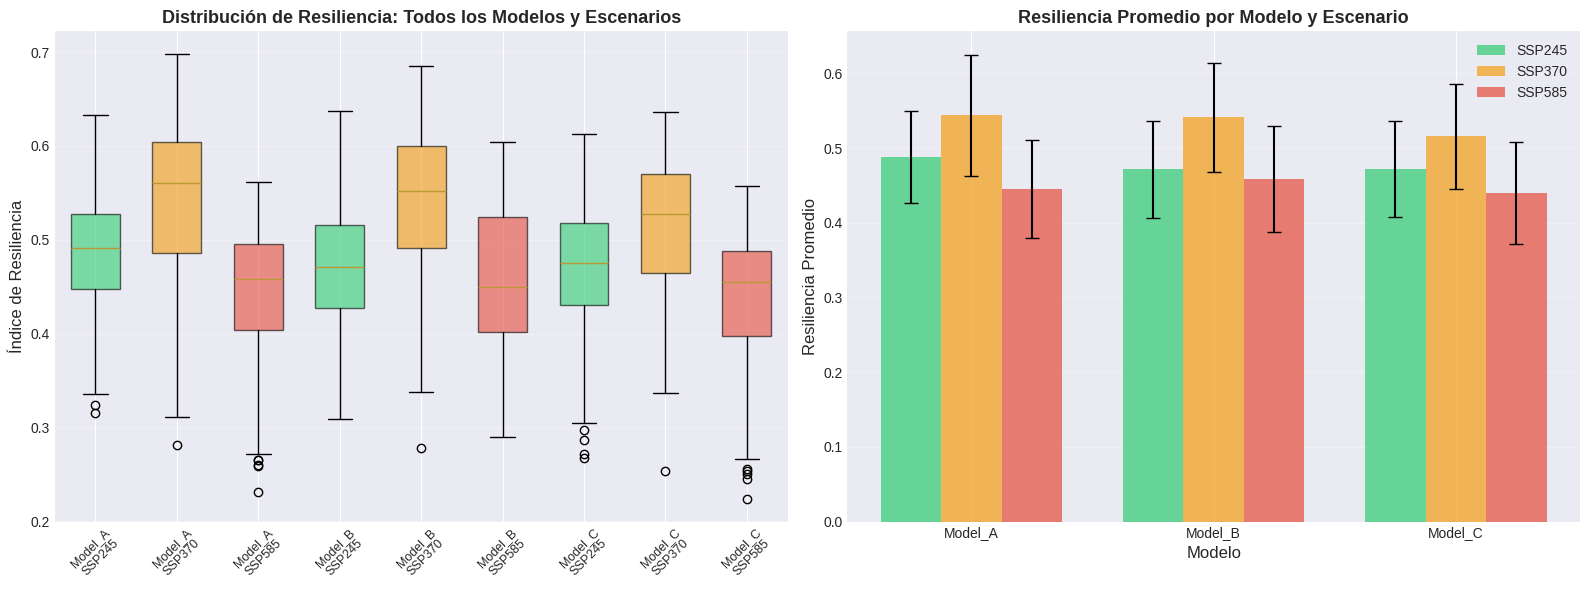


✅ Gráficos guardados en: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_analysis/resilience_multimodel_comparison_test.png


In [70]:
# === A. COMPARACIÓN INTER-MODELO ===
# ¿Los 3 modelos predicen resiliencias similares para cada escenario?

print(f"\n{'='*80}")
print(f"📊 COMPARACIÓN INTER-MODELO: Correlación de índices")
print(f"{'='*80}")

from scipy.stats import pearsonr, spearmanr

# Matriz de correlación por escenario
for scenario in ['ssp245', 'ssp370', 'ssp585']:
    print(f"\n{'='*60}")
    print(f"Escenario {scenario.upper()}")
    print(f"{'='*60}")
    
    # Extraer índices de resiliencia de cada modelo
    resilience_by_model = {}
    for model_name in resilience_results.keys():
        resilience_by_model[model_name] = resilience_results[model_name][scenario]['resilience_index']
    
    # Calcular correlaciones pairwise
    model_names = list(resilience_by_model.keys())
    n_models = len(model_names)
    
    print(f"\nCorrelaciones de Pearson:")
    print(f"{'Model Pair':<25} {'r':<8} {'p-value':<10}")
    print(f"{'-'*45}")
    
    for i in range(n_models):
        for j in range(i+1, n_models):
            model_i = model_names[i]
            model_j = model_names[j]
            
            r_pearson, p_pearson = pearsonr(
                resilience_by_model[model_i], 
                resilience_by_model[model_j]
            )
            
            print(f"{model_i} vs {model_j:<10} {r_pearson:>7.4f} {p_pearson:>10.2e}")
    
    print(f"\nCorrelaciones de Spearman (rank-based):")
    print(f"{'Model Pair':<25} {'rho':<8} {'p-value':<10}")
    print(f"{'-'*45}")
    
    for i in range(n_models):
        for j in range(i+1, n_models):
            model_i = model_names[i]
            model_j = model_names[j]
            
            rho_spearman, p_spearman = spearmanr(
                resilience_by_model[model_i], 
                resilience_by_model[model_j]
            )
            
            print(f"{model_i} vs {model_j:<10} {rho_spearman:>7.4f} {p_spearman:>10.2e}")

print(f"\n{'='*80}")
print(f"INTERPRETACIÓN:")
print(f"  - Correlación alta (r > 0.7): Modelos concuerdan en resiliencia territorial")
print(f"  - Correlación baja (r < 0.5): Modelos divergen, revisar supuestos")
print(f"{'='*80}")


# === B. COMPARACIÓN INTER-ESCENARIO ===
# ¿Cómo cambia la resiliencia con mayor forzamiento radiativo?

print(f"\n{'='*80}")
print(f"📊 COMPARACIÓN INTER-ESCENARIO: Cambio de resiliencia")
print(f"{'='*80}")

# Tabla de resiliencia promedio por modelo y escenario
summary_table = []

for model_name in resilience_results.keys():
    row = {'Model': model_name}
    
    for scenario in ['ssp245', 'ssp370', 'ssp585']:
        mean_res = resilience_results[model_name][scenario]['mean_resilience']
        std_res = resilience_results[model_name][scenario]['std_resilience']
        row[scenario.upper()] = f"{mean_res:.4f} ± {std_res:.4f}"
    
    # Calcular cambios relativos
    res_245 = resilience_results[model_name]['ssp245']['mean_resilience']
    res_370 = resilience_results[model_name]['ssp370']['mean_resilience']
    res_585 = resilience_results[model_name]['ssp585']['mean_resilience']
    
    delta_370_245 = ((res_370 - res_245) / res_245) * 100
    delta_585_245 = ((res_585 - res_245) / res_245) * 100
    
    row['Δ370-245 (%)'] = f"{delta_370_245:+.2f}"
    row['Δ585-245 (%)'] = f"{delta_585_245:+.2f}"
    
    summary_table.append(row)

df_summary = pd.DataFrame(summary_table)

print(f"\nResiliencia promedio por modelo y escenario:")
print(df_summary.to_string(index=False))

print(f"\n{'='*80}")
print(f"INTERPRETACIÓN:")
print(f"  - Δ negativo: Resiliencia disminuye con mayor forzamiento")
print(f"  - Δ positivo: Resiliencia aumenta (inusual, revisar)")
print(f"  - Consistencia entre modelos: ¿Todos predicen misma tendencia?")
print(f"{'='*80}")


# === C. VISUALIZACIÓN: BOXPLOT COMPARATIVO ===

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distribución de resiliencia por modelo (todos los escenarios)
ax1 = axes[0]

data_all = []
labels_all = []

for model_name in resilience_results.keys():
    for scenario in ['ssp245', 'ssp370', 'ssp585']:
        resilience = resilience_results[model_name][scenario]['resilience_index']
        data_all.append(resilience)
        labels_all.append(f"{model_name}\n{scenario.upper()}")

bp1 = ax1.boxplot(data_all, labels=labels_all, patch_artist=True, widths=0.6)

# Colorear por escenario
scenario_colors = {'ssp245': '#2ecc71', 'ssp370': '#f39c12', 'ssp585': '#e74c3c'}
for i, label in enumerate(labels_all):
    scenario = label.split('\n')[1].lower()
    bp1['boxes'][i].set_facecolor(scenario_colors[scenario])
    bp1['boxes'][i].set_alpha(0.6)

ax1.set_ylabel('Índice de Resiliencia', fontsize=12)
ax1.set_title('Distribución de Resiliencia: Todos los Modelos y Escenarios', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45, labelsize=9)

# Plot 2: Resiliencia promedio por escenario (comparación de modelos)
ax2 = axes[1]

x_positions = np.arange(len(resilience_results))
width = 0.25

for i, scenario in enumerate(['ssp245', 'ssp370', 'ssp585']):
    means = [resilience_results[m][scenario]['mean_resilience'] for m in resilience_results.keys()]
    stds = [resilience_results[m][scenario]['std_resilience'] for m in resilience_results.keys()]
    
    ax2.bar(
        x_positions + i * width, 
        means, 
        width, 
        yerr=stds,
        label=scenario.upper(),
        color=scenario_colors[scenario],
        alpha=0.7,
        capsize=5
    )

ax2.set_xlabel('Modelo', fontsize=12)
ax2.set_ylabel('Resiliencia Promedio', fontsize=12)
ax2.set_title('Resiliencia Promedio por Modelo y Escenario', fontsize=13, fontweight='bold')
ax2.set_xticks(x_positions + width)
ax2.set_xticklabels(list(resilience_results.keys()))
ax2.legend(loc='best', framealpha=0.9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PLOTS_DIR / f'resilience_multimodel_comparison_{MODE}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráficos guardados en: {PLOTS_DIR / f'resilience_multimodel_comparison_{MODE}.png'}")

## 💾 6. Exportar Resultados para Notebook 05_resilience

Guardar todos los resultados multi-modelo en formato compatible con análisis espacial y visualización.

In [71]:
# Exportar resultados multi-modelo para notebook 05
print(f"\n{'='*80}")
print(f"💾 EXPORTANDO RESULTADOS MULTI-MODELO")
print(f"{'='*80}")

# === 1. GUARDAR RESULTADOS DE CLUSTERING ===
clustering_output_file = RESULTS_DIR / f'clustering_multimodel_{MODE}.pkl'

with open(clustering_output_file, 'wb') as f:
    pickle.dump(clustering_results, f)

print(f"\n✅ Clustering guardado: {clustering_output_file.name}")


# === 2. GUARDAR ÍNDICES DE RESILIENCIA ===
resilience_output_file = RESULTS_DIR / f'resilience_multimodel_{MODE}.pkl'

with open(resilience_output_file, 'wb') as f:
    pickle.dump(resilience_results, f)

print(f"✅ Resiliencia guardada: {resilience_output_file.name}")


# === 3. EXPORTAR TABLAS CSV ===

# A. Resumen de resiliencia por modelo y escenario
csv_file_summary = REPORTS_DIR / f'resilience_multimodel_summary_{MODE}.csv'
df_summary.to_csv(csv_file_summary, index=False)
print(f"✅ CSV resumen: {csv_file_summary.name}")

# B. Resiliencia detallada (todos los píxeles)
all_resilience_data = []

for model_name in resilience_results.keys():
    for scenario in ['ssp245', 'ssp370', 'ssp585']:
        resilience = resilience_results[model_name][scenario]['resilience_index']
        labels = resilience_results[model_name][scenario]['labels']
        components = resilience_results[model_name][scenario]['components']
        
        for i in range(len(resilience)):
            all_resilience_data.append({
                'model': model_name,
                'scenario': scenario,
                'pixel_id': i,
                'cluster': int(labels[i]),
                'resilience_index': resilience[i],
                'cohesion': components['cohesion'][i],
                'favorabilidad': components['favorabilidad'][i],
                'estabilidad_cluster': components['estabilidad_cluster'][i],
                'exposicion_inv': components['exposicion_inv'][i]
            })

df_resilience_detailed = pd.DataFrame(all_resilience_data)
csv_file_detailed = REPORTS_DIR / f'resilience_multimodel_detailed_{MODE}.csv'
df_resilience_detailed.to_csv(csv_file_detailed, index=False)
print(f"✅ CSV detallado: {csv_file_detailed.name} ({len(df_resilience_detailed)} registros)")


# === 4. EXPORTAR METADATA ===
metadata_export = {
    'mode': MODE,
    'models': list(resilience_results.keys()),
    'scenarios': ['ssp245', 'ssp370', 'ssp585'],
    'n_features': len(feature_names),
    'feature_names': feature_names,
    'weights': WEIGHTS,
    'k_optimal_by_model_scenario': {
        model: {
            scenario: clustering_results[model][scenario]['k_optimal']
            for scenario in ['ssp245', 'ssp370', 'ssp585']
        }
        for model in clustering_results.keys()
    },
    'spatial_info': {
        'grid_shape': GRID_SHAPE,
        'mask_shape': MASK.shape if MASK is not None else None,
        'n_valid_pixels': MASK.sum() if MASK is not None else None,
        'extent': EXTENT
    }
}

metadata_file = RESULTS_DIR / f'resilience_multimodel_metadata_{MODE}.json'
with open(metadata_file, 'w') as f:
    json.dump(metadata_export, f, indent=2)

print(f"✅ Metadata: {metadata_file.name}")


# === 5. RESUMEN DE CORRELACIONES INTER-MODELO ===
correlations_data = []

for scenario in ['ssp245', 'ssp370', 'ssp585']:
    model_names = list(resilience_results.keys())
    
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            model_i = model_names[i]
            model_j = model_names[j]
            
            resilience_i = resilience_results[model_i][scenario]['resilience_index']
            resilience_j = resilience_results[model_j][scenario]['resilience_index']
            
            r_pearson, p_pearson = pearsonr(resilience_i, resilience_j)
            rho_spearman, p_spearman = spearmanr(resilience_i, resilience_j)
            
            correlations_data.append({
                'scenario': scenario,
                'model_i': model_i,
                'model_j': model_j,
                'pearson_r': r_pearson,
                'pearson_p': p_pearson,
                'spearman_rho': rho_spearman,
                'spearman_p': p_spearman
            })

df_correlations = pd.DataFrame(correlations_data)
csv_correlations = REPORTS_DIR / f'resilience_multimodel_correlations_{MODE}.csv'
df_correlations.to_csv(csv_correlations, index=False)
print(f"✅ Correlaciones: {csv_correlations.name}")


print(f"\n{'='*80}")
print(f"✅ EXPORTACIÓN COMPLETADA")
print(f"{'='*80}")

print(f"\n📁 Archivos generados:")
print(f"   1. {clustering_output_file.name} (clustering models)")
print(f"   2. {resilience_output_file.name} (resilience indices)")
print(f"   3. {csv_file_summary.name} (summary table)")
print(f"   4. {csv_file_detailed.name} (detailed data)")
print(f"   5. {metadata_file.name} (metadata)")
print(f"   6. {csv_correlations.name} (inter-model correlations)")

print(f"\n🔗 Próximo paso:")
print(f"   Usar estos archivos en notebook 05_resilience.ipynb para:")
print(f"   - Análisis espacial de resiliencia")
print(f"   - Mapas comparativos multi-modelo")
print(f"   - Identificación de zonas críticas")
print(f"   - Validación con datos externos")


💾 EXPORTANDO RESULTADOS MULTI-MODELO

✅ Clustering guardado: clustering_multimodel_test.pkl
✅ Resiliencia guardada: resilience_multimodel_test.pkl
✅ CSV resumen: resilience_multimodel_summary_test.csv
✅ CSV detallado: resilience_multimodel_detailed_test.csv (5949 registros)
✅ Metadata: resilience_multimodel_metadata_test.json
✅ Correlaciones: resilience_multimodel_correlations_test.csv

✅ EXPORTACIÓN COMPLETADA

📁 Archivos generados:
   1. clustering_multimodel_test.pkl (clustering models)
   2. resilience_multimodel_test.pkl (resilience indices)
   3. resilience_multimodel_summary_test.csv (summary table)
   4. resilience_multimodel_detailed_test.csv (detailed data)
   5. resilience_multimodel_metadata_test.json (metadata)
   6. resilience_multimodel_correlations_test.csv (inter-model correlations)

🔗 Próximo paso:
   Usar estos archivos en notebook 05_resilience.ipynb para:
   - Análisis espacial de resiliencia
   - Mapas comparativos multi-modelo
   - Identificación de zonas crític

---

## ✅ Resumen y Conclusiones del Análisis Multi-Modelo

### 📊 Resultados Obtenidos

**Clustering:**
- ✅ 9 modelos K-means entrenados (3 modelos × 3 escenarios)
- ✅ K óptimo determinado por silhouette score para cada combinación
- ✅ Separabilidad de escenarios evaluada

**Índices de Resiliencia:**
- ✅ 9 índices calculados con 4 componentes cada uno
- ✅ Pesos: Cohesión (25%), Favorabilidad (40%), Estabilidad (20%), Exposición (15%)
- ✅ Validación inter-modelo mediante correlaciones

**Comparación:**
- ✅ Correlaciones Pearson y Spearman entre modelos
- ✅ Análisis de cambios entre escenarios SSP
- ✅ Visualizaciones comparativas generadas

### 📁 Archivos Exportados

Todos los resultados están guardados en:
- `data/autoencoder_results/`
- `reports/`

Para **análisis espacial detallado** y **mapas de resiliencia**, continuar en:

**➡️ Notebook 05_resilience.ipynb**

---

